In [ ]:
%pip install xarray h5netcdf

In [1]:
import xarray as xr # xarray is like an extended pandas for (spatio-)temporal data
import matplotlib.pyplot as plt

In [2]:
filename = r'results\every7\2024-08-08_15-08-43_data.h5'
every6_dset = xr.open_dataset(filename, engine="h5netcdf")
# show the dataset. 
# This one is nice because you can click around and list all the data variables and attributes
every6_dset

<xarray.Dataset> Size: 50MB
Dimensions:       (variable: 420, time: 1000, segment: 10, epoch: 300)
Coordinates:
  * variable      (variable) <U4 7kB 'x001' 'x002' 'x003' ... 'x419' 'x420'
  * time          (time) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * segment       (segment) int64 80B 0 1 2 3 4 5 6 7 8 9
  * epoch         (epoch) int64 2kB 0 10 20 30 40 ... 2950 2960 2970 2980 2990
Data variables:
    true          (variable, time, segment) float64 34MB ...
    estimated     (variable, time, segment) float32 17MB ...
    mse_true      (segment) float32 40B ...
    mse_measured  (segment) float64 80B ...
    counts        (segment) float64 80B ...
    loss          (epoch, segment) float32 12kB ...
    measured      (variable) bool 420B ...
Attributes: (12/15)
    every:         6
    max_loops:     10
    total_loops:   1000
    trans:         3000
    D:             420
    N:             10000
    ...            ...
    len_segs:      100
    iguess_range:  [-1  4]
    epochs:        3000
    lr:            0
    lr_y0:         0.01
    seed:          0

In [ ]:
variable = 'x003'
fig, axs = plt.subplots(3, 1, figsize=(10, 8))  # 2 rows, 1 column subplot

# syntax: dataset.variable.sel(coordinate_name=coordinate_value).plot.line(...)
every6_dset.true.sel(variable=variable).plot.line(ax=axs[0], x='time', hue='segment', color='black', lw=3, add_legend=False)
every6_dset.estimated.sel(variable=variable).plot.line(ax=axs[0], x='time', hue='segment', add_legend=False)


every6_dset.mse_true.plot(ax=axs[1])

every6_dset.mse_measured.plot(ax=axs[2])

# set xlims so that the segments are aligned
axs[0].set_xlim([0, 1000])
axs[1].set_xlim([-0.5, 9.5])
axs[2].set_xlim([-0.5, 9.5])


fig.tight_layout()


In [ ]:
every6_dset.loss.plot(x='epoch', hue='segment', yscale='log')
plt.show()

Text(0.5, 1.0, 'histogram of trajectory values, mean = 2.30, std = 3.68')

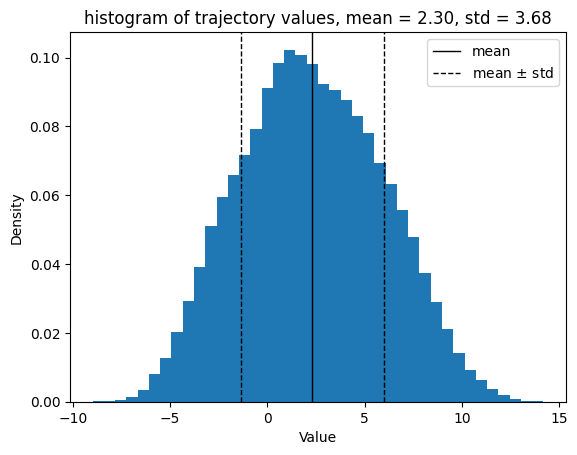

In [19]:
every6_dset.true.mean(dim='segment').plot.hist(bins=40, density=True)
plt.ylabel('Density')
plt.xlabel('Value')
mean = every6_dset.true.mean(dim='segment').mean().values
std = every6_dset.true.mean(dim='segment').std().values
# plot the mean and std as vertical lines
plt.axvline(mean, color='black', linestyle='solid', linewidth=1, label='mean')
plt.axvline(mean - std, color='black', linestyle='dashed', linewidth=1, label=r'mean $\pm$ std')
plt.axvline(mean + std, color='black', linestyle='dashed', linewidth=1)
plt.legend()

plt.title(f"histogram of trajectory values, mean = {mean:.2f}, std = {std:.2f}")


In [8]:
print('std = ', every6_dset.true.mean(dim='segment').std())
print('mean = ', every6_dset.true.mean(dim='segment').mean())

std =  <xarray.DataArray 'true' ()> Size: 8B
array(3.67548294)
mean =  <xarray.DataArray 'true' ()> Size: 8B
array(2.29872096)


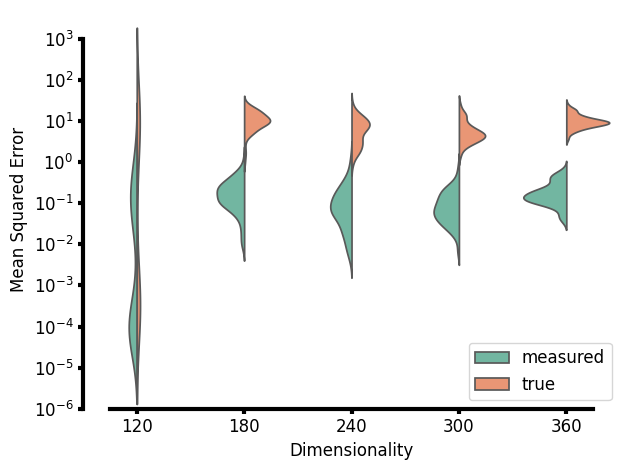

In [1]:
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dfs = {}

for filepath in glob('C:/Users/kottl/Projects/2024/adoptODE-lorenz96/results/every6/2024-10-21*.h5'):
    dset = xr.open_dataset(filepath, engine="h5netcdf")
    dimensionality = int(filepath.split('_')[-2][:-1])
    dfs[dimensionality] = pd.DataFrame({
        'MSE': [*dset.mse_measured.values, *dset.mse_true.values],
        'type': ["measured"] * len(dset.mse_measured) + ["true"] * len(dset.mse_true),
    })
    dset.close()
data = pd.concat(dfs.values(), keys=dfs.keys(), names=['dimensionality', 'index'])
fig, ax = plt.subplots()
with sns.color_palette("Set2"):
    sns.violinplot(
        data=data, 
        x='dimensionality', 
        y='MSE', 
        hue='type', 
        split=True,
        inner=None,
        log_scale=True,
        ax=ax
    )

# margins_t = (data.time.max() - data.time.min()) * 0.1
# margins_ecg = (local_ecg.max() - local_ecg.min()) * 0.1
# ax.set_xlim(90, 390)
ax.set_ylim(1e-6, 5e3)
# remove upper and right spine
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# make the lower and left spine thicker and in a "]" style
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.spines.bottom.set_bounds(-0.25, 4.25)
ax.spines.left.set_bounds(1e-6, 1e3)
# # increase the linewidth of the axis ticks
ax.xaxis.set_tick_params(width=3)
ax.yaxis.set_tick_params(width=3)
# # increase the size of the axis ticks
from matplotlib.ticker import NullLocator
ax.yaxis.set_minor_locator(NullLocator())
ax.tick_params(axis="both", which="major", labelsize=12)
ax.set_xlabel("Dimensionality", fontsize=12)
ax.set_ylabel("Mean Squared Error", fontsize=12)
ax.legend(loc='lower right', title='', fontsize=12)
fig.tight_layout()
plt.savefig('results/mse_violinplot.png', dpi=300)


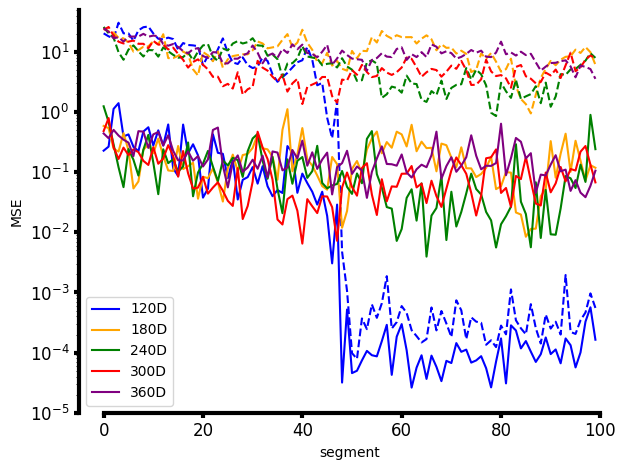

In [10]:
fig, ax = plt.subplots()
colors=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for i, filepath in enumerate(glob('C:/Users/kottl/Projects/2024/adoptODE-lorenz96/results/every6/2024-10-21*.h5')):
    dset = xr.open_dataset(filepath, engine="h5netcdf")
    dimensionality = int(filepath.split('_')[-2][:-1])
    dset.mse_measured.plot(label=f'{dimensionality}D', ax=ax, color=colors[i])
    dset.mse_true.plot(label='', ax=ax, linestyle='dashed', color=colors[i])
    dset.close()

ax.set_ylim(1e-5, 5e1)
# remove upper and right spine
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# make the lower and left spine thicker and in a "]" style
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.spines.bottom.set_bounds(0, 100)
ax.spines.left.set_bounds(1e-5, 5e1)
# # increase the linewidth of the axis ticks
ax.xaxis.set_tick_params(width=3)
ax.yaxis.set_tick_params(width=3)
# # increase the size of the axis ticks
from matplotlib.ticker import NullLocator
ax.yaxis.set_minor_locator(NullLocator())
ax.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
ax.set_yscale('log')
ax.set_ylabel('MSE')
fig.tight_layout()
plt.savefig('results/mse_plot.png', dpi=300)

In [17]:
len(data.mse_measured[data.mse_measured < 0.01])

53